# Lab 1: Basic Video Processing (2026 Version)

In this lab, you will learn how digital video can be processed frame by frame using Python.

You will:
- read a video file
- extract and display frames
- separate RGB color channels
- convert frames from RGB to YUV
- simulate chroma subsampling
- reconstruct the image
- evaluate quality using PSNR
- process a full video

This lab connects image processing, video systems, and human visual perception.

---

## Important

This is the lab notebook.  
You are expected to write code in the cells marked **TODO**.

For **downsampling** and **upsampling**, hints are provided.  
For **color conversion** and **PSNR calculation**, you will implement the key steps yourself.

## Group Information

**Group number:**  13

**Member 1:**  Nora Sennerö

**Member 2:**  Erik Esshagen


## Introduction

Digital video is a sequence of image frames shown over time. In practice, many video algorithms work by processing frames one by one.

In this lab, you will explore a simplified version of a real video processing pipeline:

1. extract a frame from a video
2. inspect its RGB channels
3. convert the frame to YUV
4. downsample the color components
5. reconstruct the frame
6. compare the original and reconstructed frame
7. apply the same process to the full video

This lab also shows an important idea in video engineering:

Human vision is more sensitive to brightness than to color.  
Because of this, color information can often be stored at lower resolution with only a small loss in perceived quality.

## Learning Objectives

After completing this lab, you should be able to:

- explain how a video is represented as a sequence of frames
- extract and display frames from a video file
- separate and visualize RGB color channels
- convert between RGB and YUV color spaces
- explain why chroma subsampling is useful
- reconstruct an image after color subsampling
- compute PSNR to measure reconstruction quality
- process and save a new video file

## Setup

Before starting, download the video file from Canvas and place it in the same folder as this notebook.

Then run the following cell to import the required libraries.

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

## Part 1: Read the Video and Extract One Frame

In this first part, you will load a video file and extract one frame.

### Task (just learn through running the codes)
- Open the video file
- Print basic information about the video
- Extract one frame
- Display the frame

Video information:
Width: 480
Height: 360
Frame rate: 30.0
Number of frames: 141


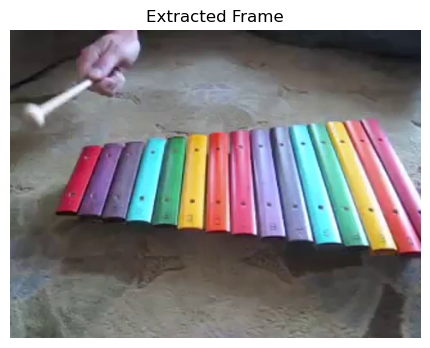

In [94]:
video_name = 'test_video.mp4'
cap = cv2.VideoCapture(video_name)

if not cap.isOpened():
    raise ValueError("Could not open the video file. Please check the filename.")

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_rate = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Video information:")
print("Width:", frame_width)
print("Height:", frame_height)
print("Frame rate:", frame_rate)
print("Number of frames:", frame_count)

ret, frame_bgr = cap.read()

if not ret:
    raise ValueError("Could not read the first frame.")

frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 4))
plt.imshow(frame_rgb)
plt.title("Extracted Frame")
plt.axis("off")
plt.show()

cap.release()

## Part 2: Display the RGB Channels

A color image is made of three channels:

- Red
- Green
- Blue

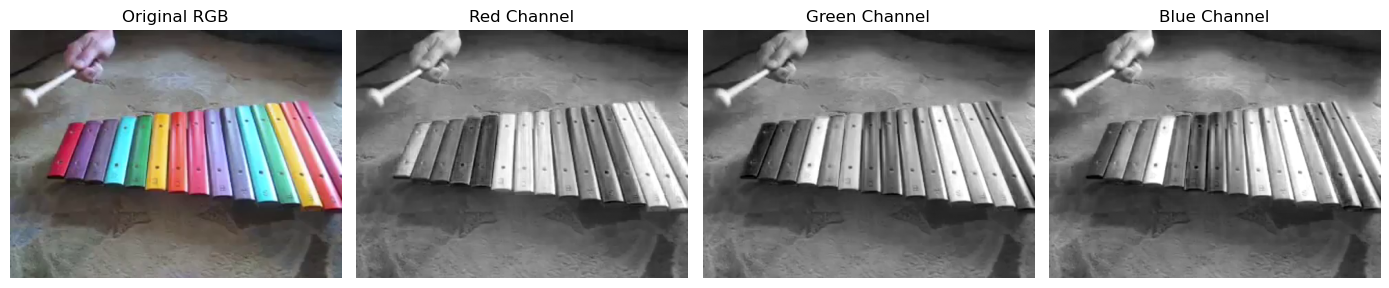

In [95]:
def dispimage(img):
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(img)
    plt.title("Original RGB")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(R, cmap='gray')
    plt.title("Red Channel")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(G, cmap='gray')
    plt.title("Green Channel")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(B, cmap='gray')
    plt.title("Blue Channel")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

dispimage(frame_rgb)

## Part 3: Convert RGB to YUV

RGB is convenient for display, but video systems often use YUV.

In YUV:
- **Y** represents brightness
- **U** and **V** represent color information

This is useful because human vision is more sensitive to brightness than to color.

### Task
Implement a function that converts an RGB image to YUV.

### Hint
Use the following equations:

- Y = 0.299R + 0.587G + 0.114B
- U = B - Y
- V = R - Y

In [96]:
def frameRGB2YUV(RGBframe):
    RGBframe = RGBframe.astype(np.float32)

    R = RGBframe[:, :, 0]
    G = RGBframe[:, :, 1]
    B = RGBframe[:, :, 2]

    Y = (0.299 * R) + (0.587 * G) + (0.114 * B)
    U = B - Y
    V = R - Y

    # TODO: return a YUV frame with shape (H, W, 3)
    YUVframe = np.stack((Y, U, V), axis=2)

    
    return YUVframe

## Part 4: Downsampling

In video systems, the color components are often stored at lower resolution than the brightness component.

### Task
Downsample the U and V channels.

### Hint
Use slicing. For example, to keep one value for each 2×2 block, you can use:

`channel[::2, ::2]`

In [97]:
def downsample_uv(U, V):
    U_sub = U[::2, ::2]
    V_sub = V[::2, ::2]
    return U_sub, V_sub

## Part 5: Upsampling

After downsampling, the U and V channels must be restored to the full image size before converting back to RGB.

### Task
Upsample U and V to the size of Y.

### Hint
You may use `cv2.resize`.

In [98]:
def upsample_uv(U_sub, V_sub, target_shape):
    target_h, target_w = target_shape
    U_up = cv2.resize(U_sub, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    V_up = cv2.resize(V_sub, (target_w, target_h), interpolation=cv2.INTER_LINEAR)

    return U_up, V_up

## Part 6: Convert YUV Back to RGB

Now reconstruct the image by converting YUV back to RGB.

### Task
Implement the inverse color conversion.

### Hint
Use the following relationships:
- R = Y + V
- B = Y + U
- G can be recovered from the Y equation

In [99]:
def frameYUV2RGB(YUVframe):
    Y = YUVframe[:, :, 0]
    U = YUVframe[:, :, 1]
    V = YUVframe[:, :, 2]

    R = Y + V
    B = Y + U
    G = (Y - (0.299*R) - (0.114*B)) / 0.587

    RGBframe = np.stack((R, G, B), axis=2)

    RGBframe = np.clip(RGBframe, 0, 255).astype(np.uint8)
    return RGBframe

## Part 7: Build One Full Pipeline

Now combine the previous steps into one function.

### Task (just running the codes to learn)
For a given RGB frame:
1. convert RGB to YUV
2. downsample U and V
3. upsample U and V
4. reconstruct the RGB image

In [100]:
def process_frame(frame_rgb):
    YUVframe = frameRGB2YUV(frame_rgb)

    Y = YUVframe[:, :, 0]
    U = YUVframe[:, :, 1]
    V = YUVframe[:, :, 2]

    U_sub, V_sub = downsample_uv(U, V)
    U_up, V_up = upsample_uv(U_sub, V_sub, Y.shape)

    YUV_reconstructed = np.stack((Y, U_up, V_up), axis=2)
    reconstructed_rgb = frameYUV2RGB(YUV_reconstructed)

    return reconstructed_rgb

## Part 8: Visual Comparison

Now test the full pipeline on one frame.

### Task (just running the codes)
Display:
- original image
- reconstructed image
- absolute difference image

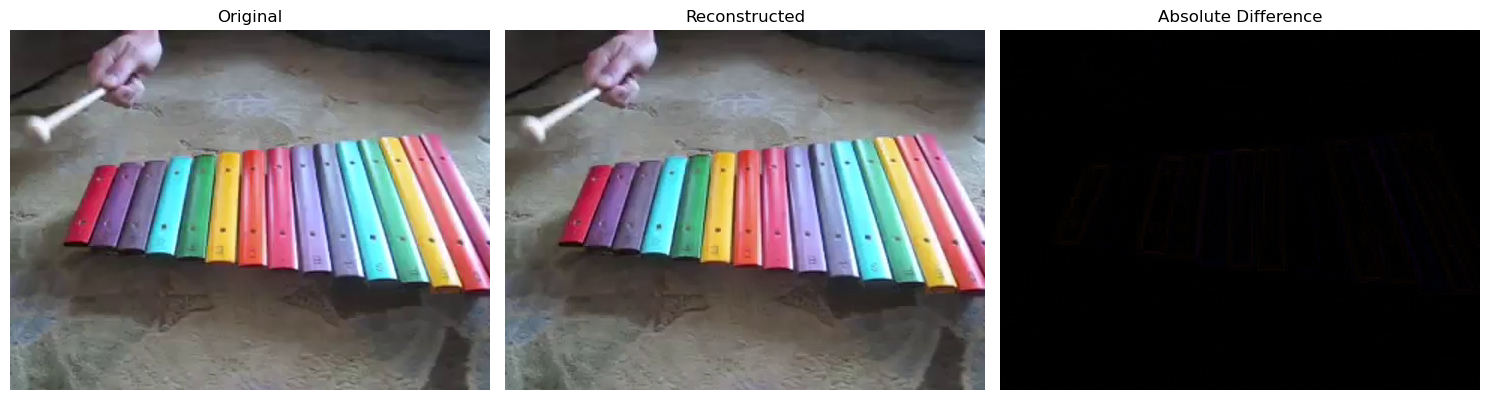

In [101]:
reconstructed_rgb = process_frame(frame_rgb)
difference = np.abs(frame_rgb.astype(np.int16) - reconstructed_rgb.astype(np.int16)).astype(np.uint8)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(frame_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(reconstructed_rgb)
plt.title("Reconstructed")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(difference)
plt.title("Absolute Difference")
plt.axis("off")

plt.tight_layout()
plt.show()

## Part 9: Compute PSNR

PSNR stands for Peak Signal-to-Noise Ratio. It is a common measure of reconstruction quality.

A higher PSNR usually means the reconstructed image is closer to the original.

### Task
Implement a function that computes PSNR between two images.

### Formula

If MSE is the mean squared error, then:

PSNR = 10 log10(255² / MSE)

In [102]:
def CalculatePSNR(im1, im2):
    if im1.shape != im2.shape:
        raise ValueError("Images must have the same shape.")

    # TODO: convert images to float
    im1 = im1.astype(np.float32)
    im2 = im2.astype(np.float32)

    # TODO: compute mean squared error
    mse = np.mean((im1 - im2) ** 2)

    if mse == 0:
        return float('inf')

    # TODO: compute PSNR
    psnr = 10 * np.log10((255**2) / mse)
    return psnr

## Part 10: Test PSNR on One Frame

Now compute PSNR for the reconstructed frame. The expected PSNR for this frame should be around: 44 dB

In [103]:
psnr_value = CalculatePSNR(frame_rgb, reconstructed_rgb)
print("PSNR for this frame:", psnr_value, "dB")

PSNR for this frame: 43.989376 dB


## Part 11: Process the Full Video

So far, you have tested the pipeline on a single frame.  
Now apply the same process to all frames in the video.

### Task
For each frame:
1. read the frame
2. convert BGR to RGB
3. process the frame
4. save the output frame
5. compute frame PSNR

At the end:
- save the new video
- plot PSNR as a function of frame number

In [104]:
video_name = 'test_video.mp4'
cap = cv2.VideoCapture(video_name)

if not cap.isOpened():
    raise ValueError("Could not open the video file.")

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_rate = cap.get(cv2.CAP_PROP_FPS)

writer = cv2.VideoWriter(
    'output.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    frame_rate,
    (frame_width, frame_height)
)

psnr_values = []
frame_index = 0

while True:
    ret, frame_bgr = cap.read()

    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    reconstructed_rgb = process_frame(frame_rgb)

    psnr = CalculatePSNR(frame_rgb, reconstructed_rgb)
    psnr_values.append(psnr)

    output_bgr = cv2.cvtColor(reconstructed_rgb, cv2.COLOR_RGB2BGR)
    writer.write(output_bgr)

    frame_index += 1

cap.release()
writer.release()

print("Finished processing video.")
print("Average PSNR:", np.mean(psnr_values), "dB")

Finished processing video.
Average PSNR: 44.38458 dB


## Part 12: Plot the PSNR Curve

Plot PSNR for all frames in the video. The expected PSNR should look like 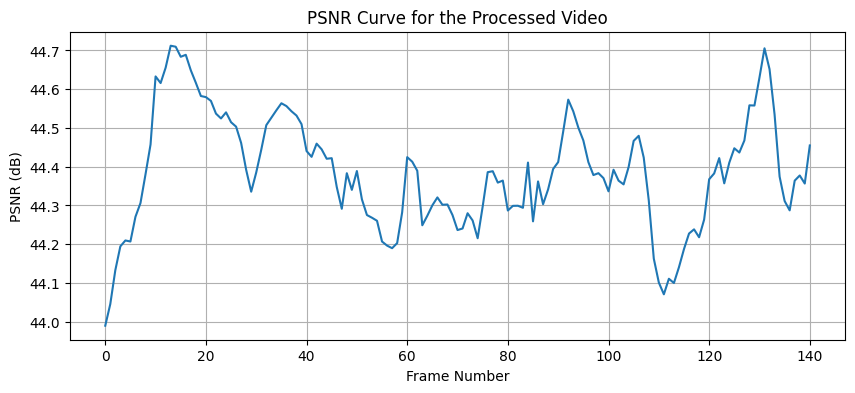

### Reflection
- Are some frames easier to reconstruct than others?
- Why might PSNR change from frame to frame?

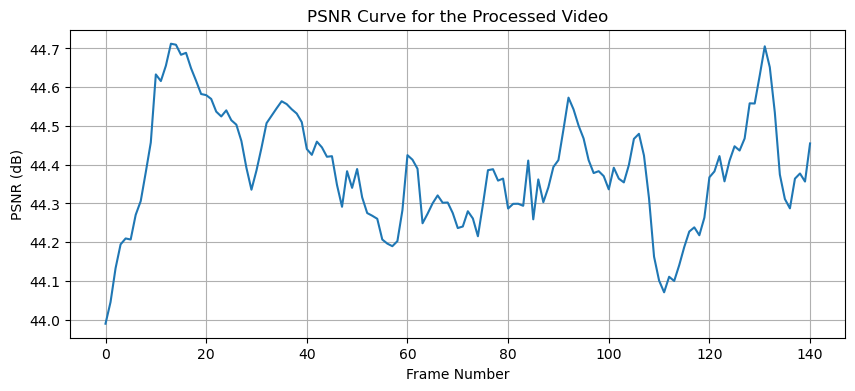

In [105]:
plt.figure(figsize=(10, 4))
plt.plot(psnr_values)
plt.xlabel("Frame Number")
plt.ylabel("PSNR (dB)")
plt.title("PSNR Curve for the Processed Video")
plt.grid(True)
plt.show()

## Part 13: Discussion Questions

Answer the following questions in your report:

1. Why is YUV more useful than RGB for video transmission?
2. Why can U and V be stored at lower resolution?
3. What visual differences do you observe after subsampling?
4. What does PSNR tell you, and what does it not tell you?
5. Why does PSNR vary from frame to frame?

## Report Instructions

Your report should contain:

1. group number and member names
2. a short explanation of RGB and YUV
3. an explanation of how you downsampled and upsampled U and V
4. original and reconstructed example images
5. difference images
6. PSNR for one frame
7. average PSNR for the whole video
8. PSNR curve across frames
9. short answers to the discussion questions

Submit:
- one PDF report
- the completed notebook